<a href="https://colab.research.google.com/github/ecundir/Signal-Analysis-Vol-I/blob/main/lab_3_conv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Guía de Uso del Laboratorio Interactivo

Este notebook de Google Colab implementa un simulador interactivo de Interferencia Intersimbólica (ISI) basado en la operación de convolución. El objetivo es que visualices cómo la "huella dactilar" del canal (h(t)) altera físicamente la señal transmitida (dos bits limpios). Para comenzar, asegúrate de ejecutar todas las celdas de código. Dado que Colab maneja elementos interactivos de forma específica, es vital activar el backend gráfico adecuado. Al principio del código, encontrarás y deberás ejecutar la línea %matplotlib widget (o en su defecto %matplotlib inline si la primera falla) para habilitar el deslizador (slider) que te permitirá controlar el canal en tiempo real.

Una vez que el simulador esté en ejecución, interactúa activamente con el deslizador etiquetado como "Retardo Eco". Mueve el slider lentamente para cambiar la posición temporal del eco en la respuesta al impulso h(t). Observa atentamente la tercera gráfica (roja): a medida que el retardo aumenta, verás cómo la "sombra" del primer bit se desplaza. Tu desafío es identificar el Umbral Crítico, marcado por la línea naranja vertical. Si el eco cruza este umbral, notarás que los bits se fusionan y el contador de picos baja, indicando una ISI crítica. Usa este control dinámico para responder a las preguntas de análisis técnico planteadas en la guía del laboratorio impreso.

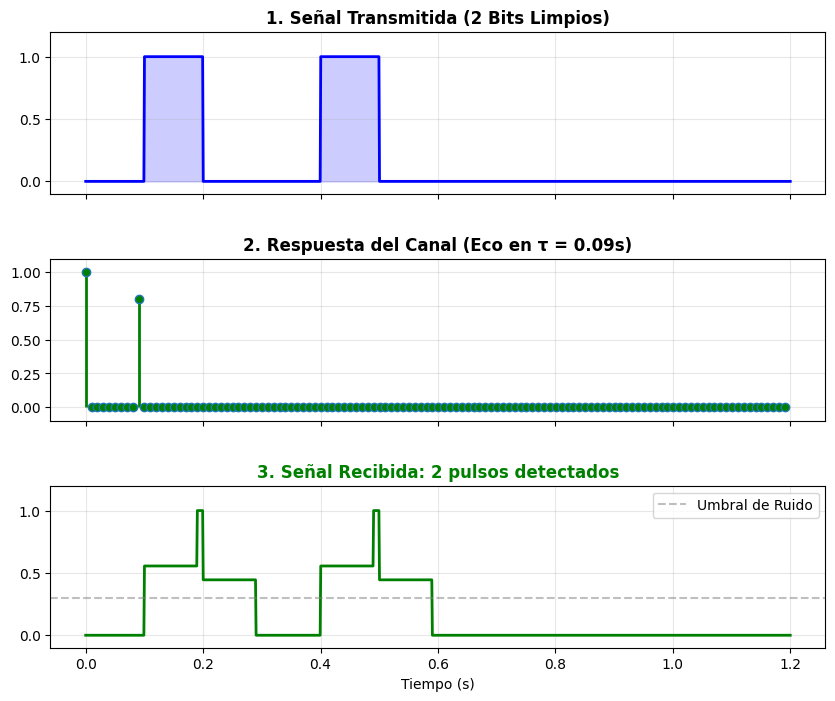

In [ ]:
# @title Simulador de Interferencia Entre Símbolos (ISI) { run: "auto" }
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from ipywidgets import interact, FloatSlider, Layout

# 1. Configuración de la señal base (2 Bits)
t = np.linspace(0, 1.2, 1200)
dt = t[1] - t[0]
# Definimos los dos pulsos originales
x = np.where(((t > 0.1) & (t < 0.2)) | ((t > 0.4) & (t < 0.5)), 1.0, 0.0)
noise_threshold = 0.3  # Umbral para detección de picos

def sim_isi(tau):
    """Calcula la respuesta del canal con un eco retardado tau"""
    h = np.zeros_like(t)
    # Impulso directo (en t=0) y Eco (en t=tau)
    h[0] = 1.0
    idx_eco = np.abs(t - tau).argmin()
    h[idx_eco] = 0.8

    # Convolución para obtener la señal recibida
    y = np.convolve(x, h, mode='full')[:len(t)] * dt

    # Normalización para visualización
    if np.max(y) > 0:
        y = y / np.max(y)

    # Detectar cuántos eventos (bits) "ve" el receptor
    pks, _ = find_peaks(y, height=noise_threshold, distance=50)
    return h, y, len(pks)

# 2. Función de actualización para el Widget
def actualizar_grafico(retardo=0.15):
    h, y, n_eventos = sim_isi(retardo)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.4)

    # Gráfico 1: Señal Original x(t)
    ax1.plot(t, x, 'b', linewidth=2)
    ax1.fill_between(t, 0, x, alpha=0.2, color='blue')
    ax1.set_title("1. Señal Transmitida (2 Bits Limpios)", fontweight='bold')
    ax1.set_ylim(-0.1, 1.2)
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Respuesta del Canal h(t)
    # Usamos stem para representar los impulsos (Directo + Eco)
    markerline, stemlines, baseline = ax2.stem(t[::10], h[::10], basefmt=" ")
    plt.setp(stemlines, 'color', 'g', 'linewidth', 2)
    plt.setp(markerline, 'markerfacecolor', 'g')
    ax2.set_title(f"2. Respuesta del Canal (Eco en τ = {retardo:.2f}s)", fontweight='bold')
    ax2.set_ylim(-0.1, 1.1)
    ax2.grid(True, alpha=0.3)

    # Gráfico 3: Señal Recibida y(t)
    color_resultado = 'g' if n_eventos == 2 else 'r'
    ax3.plot(t, y, color=color_resultado, linewidth=2)
    ax3.axhline(y=noise_threshold, color='gray', linestyle='--', alpha=0.5, label='Umbral de Ruido')
    ax3.set_title(f"3. Señal Recibida: {n_eventos} pulsos detectados",
                  color=color_resultado, fontweight='bold')
    ax3.set_xlabel("Tiempo (s)")
    ax3.set_ylim(-0.1, 1.2)
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)

    # Explicación didáctica
    if n_eventos > 2:
        ax3.text(0.6, 0.5, "¡ALERTA DE ISI!\nEl eco se confunde\ncon un nuevo bit",
                 color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

    plt.show()

# 3. Crear el Slider interactivo
interact(actualizar_grafico,
         retardo=FloatSlider(value=0.15, min=0.0, max=0.6, step=0.01,
                             description='Retardo (τ):',
                             layout=Layout(width='80%'),
                             style={'description_width': 'initial'}));